# Feature Engineering Automatizado e Interpretable con Programación Genética


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/casos_estudio/gp_feature_engineering.ipynb)


## Contexto del Problema



En la industria del Machine Learning, existe un dilema clásico: **Interpretabilidad vs. Rendimiento**.
*   Los **modelos lineales** (Regresión Logística, Ridge) son rápidos, auditables y explicables (ideales para medicina o finanzas), pero fallan si las variables tienen relaciones no lineales complejas.
*   Los **ensambles** (Random Forest, XGBoost) capturan estas relaciones no lineales a la perfección, pero son "cajas negras" difíciles de auditar.



## Objetivos y Restricciones


**Objetivo principal:** Utilizar Programación Genética (GP) para descubrir automáticamente transformaciones matemáticas no lineales (ej. $x_1 / \sqrt{x_2 + x_3}$). Estas nuevas variables actuarán como **"atajos matemáticos"** que potenciarán el rendimiento de los modelos predictivos, manteniendo la trazabilidad exacta de cómo se calculó la variable.


**Restricciones:**
- **El problema del Bloat:** Las ecuaciones generadas no pueden crecer infinitamente; deben ser legibles y auditables.
- **Redundancia:** Debemos minimizar la generación de variables que sean matemáticamente equivalentes entre sí.
- **Costo Computacional:** La búsqueda debe ser lo suficientemente eficiente para ejecutarse como un paso de preprocesamiento (EDA avanzado).

## Prerrequisitos

- Haber completado el capítulo de machine learning clásico.
- Haber completado el notebook [Programación Genética (GP): Evolucionando Estructuras y Ecuaciones](../07_programacion_genetica_gp.ipynb)


---

## Configuración del Entorno y Arquitectura del Framework


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import math
import copy
import uuid
import operator
import functools

from scipy.stats import pearsonr, spearmanr
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_diabetes, make_friedman1

try:
    import deap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "deap"], check=True)
from deap import gp, base, creator, tools, algorithms

# Fijamos semillas
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


Para mantener este notebook enfocado en la aplicación, encapsulamos el motor de Programación Genética en la siguiente celda. Este framework implementa la estrategia **HFSR (Hall of Fame Secuencial con Penalización de Redundancia)**, control de *bloat* y paralelización.

In [2]:
# @title Framework GPFeatureEngineer (Desplegar)


# =============================================================================
#                  INYECCIÓN DEL FRAMEWORK GPFeatureEngineer
#                 (Resumido, es parte del proyecto evo-suite)
# =============================================================================

from dataclasses import dataclass, field
from typing import Optional, List, Tuple, Dict, Union, Any
from sklearn.utils.validation import check_is_fitted, check_array

# ══════════════════════════════════════════════════════════════════════════════
# 1. PRIMITIVAS MATEMÁTICAS PROTEGIDAS
# ══════════════════════════════════════════════════════════════════════════════

def _protdiv(a: float, b: float) -> float:
    """División protegida: retorna 1 si denominador ≈ 0."""
    return a / b if abs(b) > 1e-10 else 1.0

def _protlog(a: float) -> float:
    """Logaritmo protegido: opera sobre |a|, retorna 0 si a ≈ 0."""
    return math.log(abs(a)) if abs(a) > 1e-10 else 0.0

def _protsqrt(a: float) -> float:
    """Raíz cuadrada protegida: opera sobre |a|."""
    return math.sqrt(abs(a))

def _protpow2(a: float) -> float:
    """Cuadrado con clipping para evitar overflow."""
    return min(a * a, 1e9)

def _protpow3(a: float) -> float:
    """Cubo con clipping."""
    return max(min(a * a * a, 1e9), -1e9)

def _sigmoid(a: float) -> float:
    """Función sigmoide: mapea ℝ → (0,1). Útil para detectar umbrales."""
    return 1.0 / (1.0 + math.exp(-max(min(a, 500), -500)))

def _relu(a: float) -> float:
    """ReLU: max(0, a). Detecta relaciones lineales por partes."""
    return max(0.0, a)

def _abs_val(a: float) -> float:
    """Valor absoluto."""
    return abs(a)

# Conjunto completo de primitivas disponibles por categoría
PRIMITIVE_SETS = {
    'basic': [
        (operator.add, 2, 'add'),
        (operator.sub, 2, 'sub'),
        (operator.mul, 2, 'mul'),
        (_protdiv,     2, 'div'),
        (operator.neg, 1, 'neg'),
        (_abs_val,     1, 'abs'),
    ],
    'extended': [
        (operator.add, 2, 'add'),
        (operator.sub, 2, 'sub'),
        (operator.mul, 2, 'mul'),
        (_protdiv,     2, 'div'),
        (_protlog,     1, 'log'),
        (_protsqrt,    1, 'sqrt'),
        (_protpow2,    1, 'sq'),
        (operator.neg, 1, 'neg'),
        (_abs_val,     1, 'abs'),
    ],
    'full': [
        (operator.add, 2, 'add'),
        (operator.sub, 2, 'sub'),
        (operator.mul, 2, 'mul'),
        (_protdiv,     2, 'div'),
        (_protlog,     1, 'log'),
        (_protsqrt,    1, 'sqrt'),
        (_protpow2,    1, 'sq'),
        (_protpow3,    1, 'cube'),
        (operator.neg, 1, 'neg'),
        (_abs_val,     1, 'abs'),
        (_sigmoid,     1, 'sigmoid'),
        (_relu,        1, 'relu'),
    ],
    'nonlinear': [
        (operator.mul, 2, 'mul'),
        (_protdiv,     2, 'div'),
        (_protlog,     1, 'log'),
        (_protsqrt,    1, 'sqrt'),
        (_protpow2,    1, 'sq'),
        (_protpow3,    1, 'cube'),
        (_sigmoid,     1, 'sigmoid'),
        (_relu,        1, 'relu'),
        (operator.neg, 1, 'neg'),
    ],
}

# ══════════════════════════════════════════════════════════════════════════════
# 2. CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class GPConfig:
    """
    Configuración del algoritmo de Programación Genética para Feature Engineering.

    Parámetros del algoritmo evolutivo
    ------------------------------------
    population_size : int
        Tamaño de la población de árboles. Valores típicos: 200–1000.
        PG requiere poblaciones mayores que AG porque el espacio de búsqueda
        es mucho más grande (árboles vs vectores binarios).

    n_generations : int
        Generaciones por cada feature generado. 30–100 es razonable.

    crossover_prob : float
        Probabilidad de aplicar crossover de subárbol. Dominante en PG: 0.7–0.9.

    mutation_prob : float
        Probabilidad de aplicar alguna mutación. Complementario al crossover.

    p_subtree_mutation : float
        Fracción de mutaciones que reemplazan un subárbol completo.

    p_hoist_mutation : float
        Fracción de mutaciones que "elevan" (hoist) un subárbol, simplificando.
        Combate el bloat.

    p_point_mutation : float
        Fracción de mutaciones que reemplazan un nodo por otro de igual aridad.

    Parámetros del árbol
    ----------------------
    init_depth_min : int
        Profundidad mínima en la inicialización (genHalfAndHalf).

    init_depth_max : int
        Profundidad máxima en la inicialización.

    max_tree_height : int
        Límite estático de altura. Evita el bloat. Crucial en PG.
        Recomendado: 6–8.

    use_constants : bool
        Si True, incluye constantes efímeras aleatorias como terminales.

    constant_range : tuple
        Rango de las constantes efímeras (min, max).

    function_set : str
        Conjunto de primitivas: 'basic', 'extended', 'full', 'nonlinear'.

    Parámetros de fitness
    ----------------------
    fitness_metric : str
        'mutual_info' : Información Mutua (captura dependencias no lineales).
                        Recomendado para la mayoría de casos.
        'correlation' : |correlación de Pearson| con el target.
                        Más rápido, solo detecta relaciones lineales.
        'spearman'    : Correlación de Spearman (rank-based, robusta).
        'model_score' : CV score de un modelo dado. Más costoso, más informativo.

    redundancy_beta : float
        Penalización por redundancia con features ya generados (en HoF).
        fitness -= beta * max_corr(nuevo, hof)
        0.0 = sin penalización (riesgo de features redundantes)
        0.3 = balance recomendado
        0.7 = alta diversidad (puede sacrificar MI)

    parsimony_coeff : float
        Coeficiente de parsimonia (penalización por tamaño del árbol):
        fitness -= parsimony * n_nodes
        Valor típico: 0.001–0.005.

    Parámetros del pipeline
    ------------------------
    n_features_to_generate : int
        Número de nuevos features a construir. Típico: 3–15.

    augment_original : bool
        Si True, los features generados se concatenan a los originales.
        Si False, solo se retornan los features generados.

    normalize_output : bool
        Si True, estandariza cada feature generado antes de retornarlo.

    redundancy_threshold : float
        Si la correlación de un nuevo feature con alguno del HoF supera
        este umbral, el feature se descarta automáticamente.

    task_type : str
        'classification', 'regression', o 'auto'.

    tournament_size : int
        Tamaño del torneo para selección. 5–7 en PG.

    elite_size : int
        Individuos elite que pasan sin modificación a la siguiente generación.

    random_seed : int or None
        Semilla para reproducibilidad.

    verbose : bool
        Si True, imprime progreso.

    warm_start_population : bool
        Si True, reutiliza la población del run anterior al generar el
        siguiente feature (convergencia más rápida).
    """
    # Algoritmo evolutivo
    population_size: int = 300
    n_generations: int = 40
    crossover_prob: float = 0.75
    mutation_prob: float = 0.20
    p_subtree_mutation: float = 0.60
    p_hoist_mutation: float = 0.15
    p_point_mutation: float = 0.25
    tournament_size: int = 5
    elite_size: int = 3

    # Árbol
    init_depth_min: int = 2
    init_depth_max: int = 4
    max_tree_height: int = 6
    use_constants: bool = True
    constant_range: Tuple[float, float] = (-2.0, 2.0)
    function_set: str = 'extended'   # 'basic','extended','full','nonlinear'

    # Fitness
    fitness_metric: str = 'mutual_info'  # 'mutual_info','correlation','spearman','model_score'
    redundancy_beta: float = 0.30
    parsimony_coeff: float = 0.002
    redundancy_threshold: float = 0.95

    # Pipeline
    n_features_to_generate: int = 5
    augment_original: bool = True
    normalize_output: bool = True
    task_type: str = 'auto'

    # Control
    random_seed: Optional[int] = 42
    verbose: bool = True
    warm_start_population: bool = True

    def __post_init__(self):
        assert self.function_set in PRIMITIVE_SETS, \
            f"function_set debe ser uno de {list(PRIMITIVE_SETS.keys())}"
        assert self.fitness_metric in ('mutual_info', 'correlation', 'spearman', 'model_score')
        assert 0.0 <= self.redundancy_beta <= 1.0
        assert 0.0 <= self.redundancy_threshold <= 1.0
        assert self.n_features_to_generate >= 1
        assert self.max_tree_height >= self.init_depth_max
        # Normalizar probabilidades de mutación
        total = self.p_subtree_mutation + self.p_hoist_mutation + self.p_point_mutation
        if abs(total - 1.0) > 0.01:
            logger.warning(
                f"Probabilidades de mutación suman {total:.2f}, normalizando a 1.0"
            )
            self.p_subtree_mutation /= total
            self.p_hoist_mutation /= total
            self.p_point_mutation /= total

    def to_dict(self) -> dict:
        return asdict(self)


@dataclass
class GeneratedFeature:
    """
    Representa un feature generado por programación genética.

    Atributos
    ---------
    expression : str
        Representación simbólica del árbol (expresión matemática legible).

    fitness : float
        Fitness del árbol al momento de ser seleccionado.

    mi_score : float
        Información Mutua real con el target (sin penalizaciones).

    redundancy_score : float
        Correlación máxima con features anteriores del HoF. 0 si es el primero.

    n_nodes : int
        Número de nodos del árbol (complejidad).

    height : int
        Altura del árbol.

    feature_index : int
        Índice del feature en el output (0-based).

    generation_found : int
        Generación en que se encontró el mejor árbol.

    values : np.ndarray
        Valores del feature generado sobre el dataset de training.
    """
    expression: str
    fitness: float
    mi_score: float
    redundancy_score: float
    n_nodes: int
    height: int
    feature_index: int
    generation_found: int
    values: np.ndarray = field(default_factory=lambda: np.array([]))

    def __repr__(self):
        return (
            f"GP-Feature[{self.feature_index}]: {self.expression}\n"
            f"  MI={self.mi_score:.4f} | Redund={self.redundancy_score:.3f} | "
            f"Nodes={self.n_nodes} | Height={self.height}"
        )


@dataclass
class GPEngineeringResult:
    """
    Resultado completo de una corrida de GP Feature Engineering.
    """
    generated_features: List[GeneratedFeature]
    X_original_shape: Tuple[int, int]
    X_transformed_shape: Tuple[int, int]
    baseline_cv_score: float
    augmented_cv_score: float
    score_improvement: float
    total_time: float
    n_evaluations: int
    config: GPConfig
    task_type: str
    scoring: str
    feature_names_original: List[str]
    feature_names_generated: List[str]

    def summary(self) -> str:
        sep = "═" * 65
        lines = [
            sep,
            "  GP Feature Engineering — Resultado",
            sep,
            f"  Dataset original      : {self.X_original_shape}",
            f"  Dataset transformado  : {self.X_transformed_shape}",
            f"  Features generados    : {len(self.generated_features)}",
            f"  Scoring               : {self.scoring}",
            f"  Baseline CV Score     : {self.baseline_cv_score:.4f}",
            f"  Augmented CV Score    : {self.augmented_cv_score:.4f}",
            f"  Mejora                : {self.score_improvement:+.4f} "
            f"({self.score_improvement/max(abs(self.baseline_cv_score),1e-9)*100:+.1f}%)",
            f"  Evaluaciones totales  : {self.n_evaluations}",
            f"  Tiempo total          : {self.total_time:.2f}s",
            "─" * 65,
            "  Expresiones simbólicas generadas:",
        ]
        for gf in self.generated_features:
            lines.append(f"    [{gf.feature_index}] MI={gf.mi_score:.4f} "
                         f"| Nodes={gf.n_nodes:2d} | {gf.expression}")
        lines.append(sep)
        return "\n".join(lines)


# ══════════════════════════════════════════════════════════════════════════════
# 3. EVALUADOR DE FITNESS
# ══════════════════════════════════════════════════════════════════════════════
class GPFitnessEvaluator:
    """
    Evaluador de fitness para árboles de PG.

    El fitness combina:
      1. Relevancia: cuánta información aporta el feature respecto a y.
      2. Diversidad: cuán diferente es de los features ya generados (HoF).
      3. Parsimonia: penalización por complejidad del árbol.

    fitness = relevancia(árbol, y)
              − beta * redundancia(árbol, hof)
              − parsimony * n_nodes

    El evaluador mantiene un cache por expresión simbólica del árbol para
    evitar re-computar features idénticos en distintas generaciones.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        pset: gp.PrimitiveSet,
        config: GPConfig,
        task_type: str,
        estimator=None,   # Solo para fitness_metric='model_score'
        scoring: str = 'r2',
    ):
        self.X = X
        self.y = y
        self.pset = pset
        self.config = config
        self.task_type = task_type
        self.estimator = estimator
        self.scoring = scoring

        # HoF: valores de los features ya aceptados (para penalización redundancia)
        self._hof_values: List[np.ndarray] = []
        # Caché: expresión str → (fitness, mi, redundancy)
        self._cache: Dict[str, Tuple[float, float, float]] = {}
        self._eval_count = 0

        # Función de relevancia según métrica
        if config.fitness_metric == 'mutual_info':
            if task_type == 'classification':
                self._relevance_fn = lambda vals: float(
                    mutual_info_classif(
                        vals.reshape(-1, 1), y, random_state=42
                    )[0]
                )
            else:
                self._relevance_fn = lambda vals: float(
                    mutual_info_regression(
                        vals.reshape(-1, 1), y, random_state=42
                    )[0]
                )
        elif config.fitness_metric == 'correlation':
            self._relevance_fn = lambda vals: abs(
                pearsonr(vals, y)[0] if np.std(vals) > 1e-10 else 0.0
            )
        elif config.fitness_metric == 'spearman':
            self._relevance_fn = lambda vals: abs(
                spearmanr(vals, y)[0] if np.std(vals) > 1e-10 else 0.0
            )
        else:  # model_score
            self._relevance_fn = self._model_score_relevance

    def _model_score_relevance(self, vals: np.ndarray) -> float:
        """Fitness basado en CV score de un modelo con el feature solo."""
        if self.estimator is None:
            return 0.0
        cv = (StratifiedKFold(3, shuffle=True, random_state=42)
              if self.task_type == 'classification'
              else KFold(3, shuffle=True, random_state=42))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            scores = cross_val_score(
                clone(self.estimator),
                vals.reshape(-1, 1), self.y,
                scoring=self.scoring, cv=cv, error_score=0.0
            )
        return float(np.mean(scores))

    def _compute_vals(self, individual) -> Optional[np.ndarray]:
        """Evalúa el árbol sobre X y retorna el vector de features resultante."""
        func = gp.compile(individual, self.pset)
        try:
            vals = np.array(
                [func(*row) for row in self.X],
                dtype=float
            )
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
            # Clipping para estabilidad numérica
            vals = np.clip(vals, -1e8, 1e8)
            return vals
        except Exception:
            return None

    def _redundancy(self, vals: np.ndarray) -> float:
        """Correlación de Pearson máxima con los features del HoF actual."""
        if not self._hof_values:
            return 0.0
        if np.std(vals) < 1e-10:
            return 1.0
        corrs = []
        for hv in self._hof_values:
            if np.std(hv) < 1e-10:
                corrs.append(0.0)
            else:
                try:
                    c, _ = pearsonr(vals, hv)
                    corrs.append(abs(c) if np.isfinite(c) else 0.0)
                except Exception:
                    corrs.append(0.0)
        return max(corrs) if corrs else 0.0

    def __call__(self, individual) -> Tuple[float]:
        """Evalúa el fitness de un árbol."""
        key = str(individual)

        if key in self._cache:
            cached_fitness = self._cache[key][0]
            return (cached_fitness,)

        self._eval_count += 1

        vals = self._compute_vals(individual)
        if vals is None or np.std(vals) < 1e-10:
            result = (0.0, 0.0, 0.0)
            self._cache[key] = result
            return (0.0,)

        # Relevancia
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                relevance = self._relevance_fn(vals)
                if not np.isfinite(relevance):
                    relevance = 0.0
            except Exception:
                relevance = 0.0

        # Redundancia con HoF actual
        redundancy = self._redundancy(vals)

        # Parsimonia
        complexity_penalty = self.config.parsimony_coeff * len(individual)

        # Fitness combinado
        fitness = (relevance
                   - self.config.redundancy_beta * redundancy
                   - complexity_penalty)
        fitness = max(0.0, fitness)

        self._cache[key] = (fitness, relevance, redundancy)
        return (fitness,)

    def get_mi_and_redundancy(self, individual) -> Tuple[float, float]:
        """Retorna (MI, redundancia) para el mejor árbol al añadirlo al HoF."""
        key = str(individual)
        if key in self._cache:
            _, mi, red = self._cache[key]
            return mi, red
        vals = self._compute_vals(individual)
        if vals is None:
            return 0.0, 0.0
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                mi = self._relevance_fn(vals)
            except Exception:
                mi = 0.0
        red = self._redundancy(vals)
        return mi, red

    def add_to_hof(self, individual):
        """Agrega el feature del árbol al HoF para penalizar redundancia futura."""
        vals = self._compute_vals(individual)
        if vals is not None and np.std(vals) > 1e-10:
            self._hof_values.append(vals.copy())
            # CRÍTICO: invalidar el caché cuando cambia el HoF.
            # El fitness de redundancia de todos los individuos cambia
            # al agregar un nuevo feature de referencia.
            self._cache.clear()

    def compute_feature_values(self, individual, X_new: np.ndarray) -> np.ndarray:
        """Evalúa el árbol sobre datos nuevos (transform)."""
        func = gp.compile(individual, self.pset)
        try:
            vals = np.array([func(*row) for row in X_new], dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
            return np.clip(vals, -1e8, 1e8)
        except Exception:
            return np.zeros(len(X_new))

    @property
    def eval_count(self) -> int:
        return self._eval_count


# ══════════════════════════════════════════════════════════════════════════════
# 4. CLASE PRINCIPAL: GPFeatureEngineer
# ══════════════════════════════════════════════════════════════════════════════
class GPFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Ingeniero de features simbólico mediante Programación Genética.

    Genera automáticamente nuevas características combinando los features
    originales mediante expresiones matemáticas evolucionadas con PG.

    Las expresiones generadas son:
      - Interpretables: φ(x) = log(x₂) · (x₅ + x₁²) es legible por un humano.
      - No lineales: capturan interacciones que modelos lineales no pueden ver.
      - Diversas: el mecanismo de penalización de redundancia fuerza variedad.
      - Parsimonias: el coeficiente de parsimonia favorece expresiones simples.

    Parámetros
    ----------
    config : GPConfig
        Configuración completa del algoritmo.
    scoring : str or None
        Métrica de evaluación downstream para medir la mejora real.
    estimator : sklearn estimator or None
        Modelo para medir la mejora downstream. Si None, se usa Ridge/LogReg.

    Interfaz sklearn
    ----------------
    Compatible con Pipeline de scikit-learn:

    >>> from sklearn.pipeline import Pipeline
    >>> pipe = Pipeline([
    ...     ('engineer', GPFeatureEngineer(config=GPConfig(n_features_to_generate=5))),
    ...     ('model', Ridge())
    ... ])
    >>> pipe.fit(X_train, y_train).score(X_test, y_test)

    Notas técnicas
    --------------
    El problema del BLOAT en PG:
      Sin restricción, los árboles crecen generación a generación sin mejorar
      el fitness (el bloat es el "ruido neutro" de la PG). Se controla con:
      (a) staticLimit en altura máxima
      (b) coeficiente de parsimonia en el fitness
      (c) operador de hoist mutation que simplifica árboles

    El problema de los TIPOS DEAP:
      Similar al GA-FeatureSelector, creator.create() es global. Usamos
      sufijo UUID por instancia para evitar colisiones.
    """

    def __init__(
        self,
        config: Optional[GPConfig] = None,
        scoring: Optional[str] = None,
        estimator=None,
    ):
        self.config = config or GPConfig()
        self.scoring = scoring
        self.estimator = estimator

        # Atributos de estado (setados en fit)
        self._pset = None
        self._toolbox = None
        self._evaluator = None
        self._best_trees = []        # Lista de PrimitiveTree (los mejores)
        self._hof_scalers = []       # Escaladores por feature generado
        self._uid = uuid.uuid4().hex[:8]  # Para tipos DEAP únicos
        self.result_: Optional[GPEngineeringResult] = None
        self._feature_names_in: Optional[List[str]] = None
        self._n_features_in: int = 0
        self._is_fitted: bool = False

    # ── API sklearn ───────────────────────────────────────────────────────────

    def fit(
        self,
        X: Union[np.ndarray, pd.DataFrame],
        y: Union[np.ndarray, pd.Series],
        sample_weight=None,
    ) -> 'GPFeatureEngineer':
        """
        Ejecuta la evolución de PG para construir nuevos features.

        El proceso:
        1. Construye el conjunto de primitivas (pset) con los features de entrada.
        2. Para cada feature a generar (1..n_features_to_generate):
           a. Evoluciona la población maximizando MI - beta*redundancia - parsimonia.
           b. El mejor árbol se agrega al HoF de referencia.
           c. Los evaluadores futuros penalizan la redundancia con este HoF.
        3. Concatena los features generados a X (si augment_original=True).
        """
        X_arr, y_arr, feature_names = self._prepare_data(X, y)
        task_type = self._infer_task_type(y_arr)
        scoring = self._resolve_scoring(task_type)
        self._feature_names_in = feature_names
        self._n_features_in = X_arr.shape[1]

        cfg = self.config
        if cfg.random_seed is not None:
            random.seed(cfg.random_seed)
            np.random.seed(cfg.random_seed)

        if cfg.verbose:
            print(f"\n{'═'*65}")
            print(f"  GP Feature Engineering | n_features_in={X_arr.shape[1]}")
            print(f"  Generando {cfg.n_features_to_generate} features nuevos")
            print(f"  Primitivas: {cfg.function_set} | Métrica: {cfg.fitness_metric}")
            print(f"  β-redundancia: {cfg.redundancy_beta} | Parsimonia: {cfg.parsimony_coeff}")
            print(f"{'─'*65}")

        # ── Baseline downstream ──────────────────────────────────────────────
        est = self._get_estimator(task_type)
        cv = self._build_cv(y_arr, task_type)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            baseline_scores = cross_val_score(
                clone(est), X_arr, y_arr,
                scoring=scoring, cv=cv, error_score=0.0
            )
        baseline_cv = float(np.mean(baseline_scores))
        if cfg.verbose:
            print(f"  Baseline CV Score ({scoring}): {baseline_cv:.4f}")
            print(f"{'─'*65}")

        # ── Construir PrimitiveSet ───────────────────────────────────────────
        self._pset = self._build_pset(X_arr.shape[1])

        # ── Crear tipos DEAP únicos por instancia ────────────────────────────
        fitness_name = f"GPFitness_{self._uid}"
        ind_name = f"GPIndividual_{self._uid}"
        if not hasattr(creator, fitness_name):
            creator.create(fitness_name, base.Fitness, weights=(1.0,))
        if not hasattr(creator, ind_name):
            creator.create(ind_name, gp.PrimitiveTree,
                           fitness=getattr(creator, fitness_name))
        IndClass = getattr(creator, ind_name)

        # ── Evaluador de fitness ─────────────────────────────────────────────
        self._evaluator = GPFitnessEvaluator(
            X=X_arr, y=y_arr,
            pset=self._pset,
            config=cfg,
            task_type=task_type,
            estimator=clone(est) if cfg.fitness_metric == 'model_score' else None,
            scoring=scoring,
        )

        # ── Construir toolbox ────────────────────────────────────────────────
        self._toolbox = self._build_toolbox(IndClass)

        # ── Evolución secuencial de features ────────────────────────────────
        t0_total = time.time()
        generated_features: List[GeneratedFeature] = []
        self._best_trees = []
        population = None  # Para warm start

        for feat_idx in range(cfg.n_features_to_generate):
            if cfg.verbose:
                print(f"\n  [Feature {feat_idx+1}/{cfg.n_features_to_generate}]")

            best_tree, gen_found, population = self._evolve_one_feature(
                feat_idx=feat_idx,
                IndClass=IndClass,
                prev_population=population if cfg.warm_start_population else None,
            )

            # Calcular MI real y redundancia del mejor árbol
            mi, redundancy = self._evaluator.get_mi_and_redundancy(best_tree)

            # ¿Es suficientemente único? (no colineal con features anteriores)
            if redundancy >= cfg.redundancy_threshold and feat_idx > 0:
                if cfg.verbose:
                    print(f"    ✗ Descartado: redundancia={redundancy:.3f} ≥ {cfg.redundancy_threshold}")
                # Intentar el segundo mejor de la última población
                second_bests = tools.selBest(population, min(5, len(population)))
                accepted = False
                for candidate in second_bests[1:]:
                    mi_c, red_c = self._evaluator.get_mi_and_redundancy(candidate)
                    if red_c < cfg.redundancy_threshold:
                        best_tree = candidate
                        mi, redundancy = mi_c, red_c
                        accepted = True
                        if cfg.verbose:
                            print(f"    ✓ Candidato alternativo aceptado (redund={red_c:.3f})")
                        break
                if not accepted and cfg.verbose:
                    print(f"    → Incluyendo de todas formas (sin alternativa viable)")

            # Agregar al HoF del evaluador
            self._evaluator.add_to_hof(best_tree)
            self._best_trees.append(best_tree)

            # Calcular valores del feature sobre X_train
            vals = self._evaluator.compute_feature_values(best_tree, X_arr)

            # Escalar si se requiere
            scaler = None
            if cfg.normalize_output:
                scaler = StandardScaler()
                vals = scaler.fit_transform(vals.reshape(-1, 1)).ravel()
            self._hof_scalers.append(scaler)

            gf = GeneratedFeature(
                expression=str(best_tree),
                fitness=float(best_tree.fitness.values[0]),
                mi_score=mi,
                redundancy_score=redundancy,
                n_nodes=len(best_tree),
                height=best_tree.height,
                feature_index=feat_idx,
                generation_found=gen_found,
                values=vals.copy(),
            )
            generated_features.append(gf)

            if cfg.verbose:
                print(f"    Expr: {str(best_tree)}")
                print(f"    MI={mi:.4f} | Redund={redundancy:.3f} "
                      f"| Nodes={len(best_tree)} | Gen={gen_found}")

        total_time = time.time() - t0_total

        # ── Evaluar mejora downstream ─────────────────────────────────────────
        X_aug = self._build_augmented(X_arr, generated_features)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            aug_scores = cross_val_score(
                clone(est), X_aug, y_arr,
                scoring=scoring, cv=cv, error_score=0.0
            )
        augmented_cv = float(np.mean(aug_scores))
        improvement = augmented_cv - baseline_cv

        # Nombres de features generados
        feat_names_gen = [f"gp_{i}_{gf.expression[:30]}"
                          for i, gf in enumerate(generated_features)]

        self.result_ = GPEngineeringResult(
            generated_features=generated_features,
            X_original_shape=X_arr.shape,
            X_transformed_shape=X_aug.shape,
            baseline_cv_score=baseline_cv,
            augmented_cv_score=augmented_cv,
            score_improvement=improvement,
            total_time=total_time,
            n_evaluations=self._evaluator.eval_count,
            config=cfg,
            task_type=task_type,
            scoring=scoring,
            feature_names_original=feature_names,
            feature_names_generated=feat_names_gen,
        )

        self._is_fitted = True

        if cfg.verbose:
            print(f"\n{self.result_.summary()}")

        return self

    def transform(
        self,
        X: Union[np.ndarray, pd.DataFrame],
    ) -> np.ndarray:
        """
        Transforma X aplicando los árboles GP aprendidos.
        Si augment_original=True, retorna [X_original | features_GP].
        """
        check_is_fitted(self, '_is_fitted')
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.array(X, dtype=float)

        if X_arr.shape[1] != self._n_features_in:
            raise ValueError(
                f"X tiene {X_arr.shape[1]} features, se esperaban {self._n_features_in}"
            )

        gp_features = []
        for tree, scaler in zip(self._best_trees, self._hof_scalers):
            vals = self._evaluator.compute_feature_values(tree, X_arr)
            if scaler is not None:
                vals = scaler.transform(vals.reshape(-1, 1)).ravel()
            gp_features.append(vals)

        X_gp = np.column_stack(gp_features)  # (n_samples, n_features_generated)

        if self.config.augment_original:
            return np.hstack([X_arr, X_gp])
        return X_gp

    def get_feature_names_out(self, input_features=None) -> List[str]:
        """Retorna los nombres de los features de salida."""
        check_is_fitted(self, '_is_fitted')
        if self.config.augment_original:
            orig = self._feature_names_in or [f"x{i}" for i in range(self._n_features_in)]
            gen = [f"gp_{i}" for i in range(len(self._best_trees))]
            return orig + gen
        return [f"gp_{i}" for i in range(len(self._best_trees))]

    # ── Evolución de un feature individual ────────────────────────────────────

    def _evolve_one_feature(
        self,
        feat_idx: int,
        IndClass,
        prev_population=None,
    ) -> Tuple[Any, int, List]:
        """
        Evoluciona la población para generar un único feature óptimo.

        Retorna (mejor_árbol, generación_encontrada, población_final)
        """
        cfg = self.config
        toolbox = self._toolbox

        # Inicialización de la población
        if prev_population is not None and cfg.warm_start_population:
            # Reutilizar población anterior pero reinvalidar fitness
            # (porque el HoF cambió → el fitness de redundancia cambió)
            population = list(map(toolbox.clone, prev_population))
            for ind in population:
                del ind.fitness.values
        else:
            population = toolbox.population(n=cfg.population_size)

        # Evaluación inicial
        fitnesses = list(map(toolbox.evaluate, population))
        for ind, fit in zip(population, fitnesses):
            ind.fitness.values = fit

        best_ever = tools.selBest(population, 1)[0]
        best_ever = toolbox.clone(best_ever)
        best_gen = 0
        stagnation = 0

        for gen in range(cfg.n_generations):
            # Elitismo
            elites = [toolbox.clone(e)
                      for e in tools.selBest(population, cfg.elite_size)]

            # Selección
            offspring = toolbox.select(population, len(population))
            offspring = list(map(toolbox.clone, offspring))

            # Crossover (subárbol)
            for c1, c2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < cfg.crossover_prob:
                    toolbox.mate(c1, c2)
                    del c1.fitness.values
                    del c2.fitness.values

            # Mutación (mixta: subtree / hoist / point)
            for mutant in offspring:
                if random.random() < cfg.mutation_prob:
                    r = random.random()
                    if r < cfg.p_subtree_mutation:
                        toolbox.mutate_subtree(mutant)
                    elif r < cfg.p_subtree_mutation + cfg.p_hoist_mutation:
                        toolbox.mutate_hoist(mutant)
                    else:
                        toolbox.mutate_point(mutant)
                    del mutant.fitness.values

            # Re-evaluación
            invalid = [ind for ind in offspring if not ind.fitness.valid]
            fitnesses_new = list(map(toolbox.evaluate, invalid))
            for ind, fit in zip(invalid, fitnesses_new):
                ind.fitness.values = fit

            # Insertar élites (reemplaza los peores)
            offspring.sort(key=lambda ind: ind.fitness.values[0])
            for i, elite in enumerate(elites):
                offspring[i] = elite

            population[:] = offspring

            # Tracking del mejor global
            gen_best = tools.selBest(population, 1)[0]
            if gen_best.fitness.values[0] > best_ever.fitness.values[0]:
                best_ever = toolbox.clone(gen_best)
                best_gen = gen
                stagnation = 0
            else:
                stagnation += 1

            if cfg.verbose and (gen % 10 == 0 or gen == cfg.n_generations - 1):
                fits = [ind.fitness.values[0] for ind in population]
                sizes = [len(ind) for ind in population]
                print(f"    Gen {gen:3d} | BestFit={max(fits):.4f} "
                      f"| MeanFit={np.mean(fits):.4f} "
                      f"| MeanNodes={np.mean(sizes):.1f}")

            # Early stopping por estancamiento
            if stagnation >= 20:
                if cfg.verbose:
                    print(f"    → Early stopping en gen {gen} (estancamiento)")
                break

        return best_ever, best_gen, population

    # ── Construcción del PrimitiveSet ─────────────────────────────────────────

    def _build_pset(self, n_features: int) -> gp.PrimitiveSet:
        """Construye el conjunto de primitivas para los árboles GP."""
        cfg = self.config
        pset = gp.PrimitiveSet(f'MAIN_{self._uid}', n_features)

        # Renombrar argumentos con nombres originales si disponibles
        for i in range(n_features):
            name = (self._feature_names_in[i]
                    if self._feature_names_in and i < len(self._feature_names_in)
                    else f'x{i}')
            # Sanitizar nombre para DEAP (sin espacios ni caracteres especiales)
            safe_name = name.replace(' ', '_').replace('-', '_').replace('.', '_')
            safe_name = ''.join(c for c in safe_name if c.isalnum() or c == '_')
            if not safe_name or safe_name[0].isdigit():
                safe_name = f'x{i}'
            pset.renameArguments(**{f'ARG{i}': safe_name})

        # Agregar primitivas según función_set
        for func, arity, name in PRIMITIVE_SETS[cfg.function_set]:
            pset.addPrimitive(func, arity, name=name)

        # Constantes efímeras
        if cfg.use_constants:
            lo, hi = cfg.constant_range
            pset.addEphemeralConstant(
                f'rc_{self._uid}',
                functools.partial(random.uniform, lo, hi)
            )

        return pset

    # ── Construcción del Toolbox ──────────────────────────────────────────────

    def _build_toolbox(self, IndClass) -> base.Toolbox:
        """Configura el toolbox DEAP con todos los operadores de PG."""
        cfg = self.config
        pset = self._pset
        toolbox = base.Toolbox()

        # Generación de árboles
        toolbox.register(
            'expr',
            gp.genHalfAndHalf,
            pset=pset,
            min_=cfg.init_depth_min,
            max_=cfg.init_depth_max,
        )
        toolbox.register(
            'individual',
            tools.initIterate,
            IndClass,
            toolbox.expr
        )
        toolbox.register('population', tools.initRepeat, list, toolbox.individual)
        toolbox.register('clone', copy.deepcopy)

        # Evaluación
        toolbox.register('evaluate', self._evaluator)

        # Selección
        toolbox.register('select', tools.selTournament, tournsize=cfg.tournament_size)

        # Crossover: intercambio de subárboles
        toolbox.register('mate', gp.cxOnePoint)

        # Mutaciones
        toolbox.register('expr_mut_full', gp.genFull, min_=0, max_=2)
        toolbox.register('mutate_subtree', gp.mutUniform,
                         expr=toolbox.expr_mut_full, pset=pset)
        # gp.mutShrink equivale al hoist: contrae el árbol seleccionando
        # un subárbol más pequeño (reduce bloat eficazmente)
        toolbox.register('mutate_hoist', gp.mutShrink)
        toolbox.register('mutate_point', gp.mutNodeReplacement, pset=pset)

        # Límite estático de altura (anti-bloat) — crítico en PG
        height_limit = gp.staticLimit(
            key=operator.attrgetter('height'),
            max_value=cfg.max_tree_height
        )
        toolbox.decorate('mate', height_limit)
        toolbox.decorate('mutate_subtree', height_limit)

        return toolbox

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _build_augmented(
        self,
        X_arr: np.ndarray,
        generated_features: List[GeneratedFeature]
    ) -> np.ndarray:
        """Construye el dataset aumentado con los features generados."""
        if not generated_features:
            return X_arr
        gp_block = np.column_stack([gf.values for gf in generated_features])
        if self.config.augment_original:
            return np.hstack([X_arr, gp_block])
        return gp_block

    def _prepare_data(
        self, X, y
    ) -> Tuple[np.ndarray, np.ndarray, List[str]]:
        if isinstance(X, pd.DataFrame):
            feature_names = list(X.columns)
            X = X.values.astype(float)
        else:
            X = np.array(X, dtype=float)
            n = X.shape[1]
            feature_names = [f'x{i}' for i in range(n)]
        y = np.array(y)
        if y.dtype == object or str(y.dtype).startswith('str'):
            y = LabelEncoder().fit_transform(y)
        return X, y.astype(float), feature_names

    def _infer_task_type(self, y: np.ndarray) -> str:
        if self.config.task_type != 'auto':
            return self.config.task_type
        unique = np.unique(y)
        if (len(unique) <= 20 and
                np.all(y == y.astype(int)) and
                len(unique) <= len(y) * 0.1):
            return 'classification'
        return 'regression'

    def _resolve_scoring(self, task_type: str) -> str:
        if self.scoring is not None:
            return self.scoring
        return 'accuracy' if task_type == 'classification' else 'r2'

    def _build_cv(self, y, task_type):
        seed = self.config.random_seed
        if task_type == 'classification':
            return StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        return KFold(n_splits=5, shuffle=True, random_state=seed)

    def _get_estimator(self, task_type: str):
        if self.estimator is not None:
            return self.estimator
        if task_type == 'classification':
            from sklearn.linear_model import LogisticRegression
            return LogisticRegression(max_iter=300, random_state=42)
        from sklearn.linear_model import Ridge
        return Ridge(alpha=1.0)

# ══════════════════════════════════════════════════════════════════════════════
# 5. VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════
class GPPlotter:
    """
    Visualizaciones para GP Feature Engineering.
    """

    @staticmethod
    def plot_feature_quality(result: GPEngineeringResult, figsize=(13, 5)):
        """Gráfico de MI score, redundancia y complejidad de los features generados."""
        import matplotlib.pyplot as plt

        gf_list = result.generated_features
        n = len(gf_list)
        idx = range(n)
        labels = [f"gp_{i}\n{gf.expression[:20]}..." if len(gf.expression) > 20
                  else f"gp_{i}\n{gf.expression}"
                  for i, gf in enumerate(gf_list)]

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        # MI scores
        ax = axes[0]
        bars = ax.bar(idx, [gf.mi_score for gf in gf_list],
                      color='#2ecc71', edgecolor='black', alpha=0.85)
        ax.set_xticks(idx)
        ax.set_xticklabels([f"gp_{i}" for i in idx], fontsize=9)
        ax.set_ylabel("Información Mutua con Target")
        ax.set_title("MI Score de cada Feature GP")
        ax.grid(True, alpha=0.3, axis='y')
        for bar, gf in zip(bars, gf_list):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{gf.mi_score:.3f}', ha='center', va='bottom', fontsize=8)

        # Redundancia
        ax = axes[1]
        colors_red = ['#2ecc71' if gf.redundancy_score < 0.3 else
                      '#f39c12' if gf.redundancy_score < 0.6 else '#e74c3c'
                      for gf in gf_list]
        ax.bar(idx, [gf.redundancy_score for gf in gf_list],
               color=colors_red, edgecolor='black', alpha=0.85)
        ax.axhline(result.config.redundancy_threshold, color='red',
                   linestyle='--', label=f'Umbral ({result.config.redundancy_threshold})')
        ax.set_xticks(idx)
        ax.set_xticklabels([f"gp_{i}" for i in idx], fontsize=9)
        ax.set_ylabel("Redundancia (corr. con HoF anterior)")
        ax.set_title("Redundancia entre Features GP")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        # Complejidad (n_nodes)
        ax = axes[2]
        ax.bar(idx, [gf.n_nodes for gf in gf_list],
               color='#9b59b6', edgecolor='black', alpha=0.85)
        ax.set_xticks(idx)
        ax.set_xticklabels([f"gp_{i}" for i in idx], fontsize=9)
        ax.set_ylabel("Número de Nodos")
        ax.set_title("Complejidad del Árbol")
        ax.grid(True, alpha=0.3, axis='y')

        plt.suptitle("Calidad de Features Generados por PG", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_improvement_comparison(
        results: List[Dict],
        figsize=(13, 5),
        title="Benchmark GP Feature Engineering"
    ):
        """Compara la mejora de score en múltiples datasets."""
        import matplotlib.pyplot as plt

        names = [r['name'] for r in results]
        baselines = [r['baseline_cv'] for r in results]
        augmented = [r['augmented_cv'] for r in results]
        improvements = [a - b for a, b in zip(augmented, baselines)]
        n_feats_gen = [r['n_features_generated'] for r in results]
        times = [r['time_seconds'] for r in results]

        x = np.arange(len(names))
        width = 0.35

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        # CV Score comparison
        ax = axes[0]
        ax.bar(x - width/2, baselines, width, label='Baseline (orig)',
               color='#3498db', alpha=0.85, edgecolor='black')
        ax.bar(x + width/2, augmented, width, label='GP Augmented',
               color='#2ecc71', alpha=0.85, edgecolor='black')
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel("CV Score")
        ax.set_title("Baseline vs GP Augmented")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        # Mejora relativa
        ax = axes[1]
        colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]
        bars = ax.bar(x, improvements, color=colors, edgecolor='black', alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel("Δ CV Score")
        ax.set_title("Mejora por GP Feature Engineering")
        ax.grid(True, alpha=0.3, axis='y')
        for bar, imp in zip(bars, improvements):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.001 if imp >= 0 else -0.003),
                    f'{imp:+.3f}', ha='center',
                    va='bottom' if imp >= 0 else 'top', fontsize=8)

        # Tiempo
        ax = axes[2]
        ax.bar(x, times, color='#e67e22', edgecolor='black', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
        ax.set_ylabel("Tiempo (s)")
        ax.set_title("Tiempo de Ejecución")
        ax.grid(True, alpha=0.3, axis='y')

        plt.suptitle(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_mi_comparison(
        result: GPEngineeringResult,
        X_original: np.ndarray,
        y: np.ndarray,
        figsize=(12, 5)
    ):
        """Compara la MI de features originales vs features GP generados."""
        import matplotlib.pyplot as plt

        task_type = result.task_type
        if task_type == 'classification':
            mi_orig = mutual_info_classif(
                X_original, y.astype(int), random_state=42
            )
        else:
            mi_orig = mutual_info_regression(X_original, y, random_state=42)

        mi_gp = [gf.mi_score for gf in result.generated_features]

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # Features originales
        ax = axes[0]
        feat_orig_names = result.feature_names_original
        sorted_idx = np.argsort(mi_orig)[::-1]
        ax.barh(
            range(len(mi_orig)),
            mi_orig[sorted_idx],
            color='#3498db', edgecolor='black', alpha=0.85
        )
        ax.set_yticks(range(len(mi_orig)))
        ax.set_yticklabels([feat_orig_names[i] for i in sorted_idx], fontsize=8)
        ax.set_xlabel("Información Mutua con Target")
        ax.set_title("Features Originales\n(ordenados por MI)")
        ax.axvline(max(mi_orig), color='red', linestyle='--', linewidth=1,
                   label=f'Mejor orig: {max(mi_orig):.4f}')
        ax.legend(fontsize=8)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        # Features GP
        ax = axes[1]
        ax.barh(range(len(mi_gp)), mi_gp, color='#2ecc71',
                edgecolor='black', alpha=0.85)
        ax.set_yticks(range(len(mi_gp)))
        ax.set_yticklabels(
            [f"gp_{i}" for i in range(len(mi_gp))], fontsize=8
        )
        ax.set_xlabel("Información Mutua con Target")
        ax.set_title("Features GP Generados\n(en orden de generación)")
        ax.axvline(max(mi_orig), color='red', linestyle='--', linewidth=1,
                   label=f'Mejor orig: {max(mi_orig):.4f}')
        ax.legend(fontsize=8)
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        plt.suptitle(
            f"MI: Features Originales vs GP Generados\n"
            f"(Mejora CV: {result.baseline_cv_score:.4f} → {result.augmented_cv_score:.4f})",
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

## Diseño de la Arquitectura: El Framework HFSR



Si le pedimos a un Algoritmo Genético que genere 5 características a la vez, la población entera convergerá hacia la misma fórmula matemática (la que dé el mejor *fitness*). Terminaríamos con 5 variables idénticas.

Para evitar esto, nuestro framework implementa **HFSR (Hall of Fame Secuencial con Penalización de Redundancia)**.
1. Evolucionamos 1 característica y la guardamos en el *Hall of Fame* (HoF).
2. Evolucionamos la 2da característica, pero **penalizamos su correlación** con la 1ra.
3. Repetimos el proceso.

La función de *fitness* maestra que evalúa cada árbol $T$ es:
$$ \text{Fitness}(T) = MI(\varphi_T(X), y) - \beta \cdot \max_j \text{Corr}(\varphi_T(X), \text{HoF}_j(X)) - \gamma \cdot |T| $$

*   **$MI$ (Información Mutua):** Captura qué tanto explica la nueva variable a la variable objetivo $y$ (incluso relaciones no lineales).
*   **$\beta$ (Redundancia):** Penaliza si la nueva variable se parece mucho a las que ya descubrimos.
*   **$\gamma$ (Parsimonia):** Penaliza el tamaño del árbol $|T|$ para evitar el *Bloat* (ecuaciones gigantes e incomprensibles).


## Caso de Estudio 1: Prueba de con Friedman #1



Antes de confiar en el algoritmo con datos reales, realizamos una "Prueba de Cordura" (Sanity Check). Usamos el dataset sintético **Friedman #1**, cuya función generadora es conocida:

$$ y = 10\sin(\pi x_0 x_1) + 20(x_2 - 0.5)^2 + 10x_3 + 5x_4 + \epsilon $$

*   Solo $x_0, x_1, x_2, x_3, x_4$ son relevantes. El resto ($x_5 \dots x_9$) son ruido puro.
*   Existen interacciones multiplicativas ($x_0 \cdot x_1$) y cuadráticas ($x_2^2$).

**Hipótesis:** El GP debería descubrir exactamente estas interacciones matemáticas, obteniendo nuevas variables más informativas.

In [3]:
# 1. Generamos el dataset de Friedman
X_fried, y_fried = make_friedman1(n_samples=500, n_features=10, noise=0.5, random_state=SEED)
feat_names_fried = [f'x{i}' for i in range(10)]

# 2. Baseline: Regresión Lineal (Ridge) con los features originales
cv5 = KFold(5, shuffle=True, random_state=SEED)
baseline_fried = cross_val_score(Ridge(), X_fried, y_fried, scoring='r2', cv=cv5)
print(f"Baseline R² (Ridge, features originales): {np.mean(baseline_fried):.4f}")

# 3. Ejecutamos el GP Feature Engineer
config_fried = GPConfig(
    population_size=350,
    n_generations=60,
    n_features_to_generate=3,
    function_set='extended', # Incluimos multiplicaciones y cuadrados
    fitness_metric='mutual_info',
    redundancy_beta=0.30,
    parsimony_coeff=0.003,
    max_tree_height=7,
    task_type='regression',
    verbose=True
)

print("\nEvolucionando nuevas características con GP... (Esto tomará unos segundos)")
engineer_fried = GPFeatureEngineer(config=config_fried)
engineer_fried.fit(X_fried, y_fried)
r_fried = engineer_fried.result_

Baseline R² (Ridge, features originales): 0.7531

Evolucionando nuevas características con GP... (Esto tomará unos segundos)

═════════════════════════════════════════════════════════════════
  GP Feature Engineering | n_features_in=10
  Generando 3 features nuevos
  Primitivas: extended | Métrica: mutual_info
  β-redundancia: 0.3 | Parsimonia: 0.003
─────────────────────────────────────────────────────────────────
  Baseline CV Score (r2): 0.7531
─────────────────────────────────────────────────────────────────

  [Feature 1/3]
    Gen   0 | BestFit=0.5486 | MeanFit=0.0885 | MeanNodes=5.3
    Gen  10 | BestFit=0.8090 | MeanFit=0.4930 | MeanNodes=11.7
    Gen  20 | BestFit=0.8951 | MeanFit=0.5541 | MeanNodes=15.3
    Gen  30 | BestFit=0.8951 | MeanFit=0.6368 | MeanNodes=15.8
    → Early stopping en gen 38 (estancamiento)
    Expr: mul(x0, mul(x1, add(add(x3, x4), sq(add(x3, sq(add(x3, x4)))))))
    MI=0.9401 | Redund=0.000 | Nodes=15 | Gen=18

  [Feature 2/3]
    Gen   0 | BestFit=0.59

In [4]:
# 4. Análisis de las Ecuaciones Descubiertas
print("\n--- Ecuaciones Descubiertas por el GP ---")
for gf in r_fried.generated_features:
    # Analizamos si el GP descubrió la verdad subyacente
    uses_x0x1 = 'x0' in gf.expression and 'x1' in gf.expression
    uses_x2 = 'x2' in gf.expression
    uses_noise = any(f'x{i}' in gf.expression for i in range(5, 10))

    tags = []
    if uses_x0x1: tags.append("✓ Interacción x0·x1 descubierta")
    if uses_x2:   tags.append("✓ Relación de x2 descubierta")
    if uses_noise: tags.append("CUIDADO: Incluye ruido")

    print(f"Feature [{gf.feature_index}]: {gf.expression[:60]}")
    if tags: print(f"          -> {' | '.join(tags)}")


--- Ecuaciones Descubiertas por el GP ---
Feature [0]: mul(x0, mul(x1, add(add(x3, x4), sq(add(x3, sq(add(x3, x4)))
          -> ✓ Interacción x0·x1 descubierta
Feature [1]: mul(x0, mul(x1, add(sqrt(x3), sq(add(x3, sq(add(x3, x4))))))
          -> ✓ Interacción x0·x1 descubierta
Feature [2]: mul(x0, mul(x1, add(sqrt(x3), sq(add(x3, sq(add(x3, x4))))))
          -> ✓ Interacción x0·x1 descubierta


### Comparativa de Modelos


Veamos si nuestras nuevas características lograron mejorar el rendimiento predictivo. Evaluamos tanto un modelo lineal (`Ridge`) como un ensamble no lineal (`RandomForest`).


In [5]:
print("\n--- Comparación de Estrategias en Friedman #1 ---")
print(f"{'Estrategia':35s} | {'R² (5-CV)':>10}")
print("─" * 50)

# 1. Ridge baseline
print(f"{'Ridge (features originales)':35s} | {np.mean(baseline_fried):10.4f}")

# 2. Ridge + GP features
X_aug_fried = engineer_fried.transform(X_fried)
s_aug_ridge = cross_val_score(Ridge(), X_aug_fried, y_fried, scoring='r2', cv=cv5)
print(f"{'Ridge + GP features':35s} | {np.mean(s_aug_ridge):10.4f}")

# 3. Random Forest Baseline
rf = RandomForestRegressor(100, random_state=SEED)
s_rf_base = cross_val_score(rf, X_fried, y_fried, scoring='r2', cv=cv5)
print(f"{'RandomForest (features orig)':35s} | {np.mean(s_rf_base):10.4f}")

# 4. Random Forest + GP features
s_rf_aug = cross_val_score(rf, X_aug_fried, y_fried, scoring='r2', cv=cv5)
print(f"{'RandomForest + GP features':35s} | {np.mean(s_rf_aug):10.4f}")


--- Comparación de Estrategias en Friedman #1 ---
Estrategia                          |  R² (5-CV)
──────────────────────────────────────────────────
Ridge (features originales)         |     0.7531
Ridge + GP features                 |     0.7482
RandomForest (features orig)        |     0.8289
RandomForest + GP features          |     0.8807



**Diagnóstico de Modelos:**  
Observar los resultados empíricos con atención. El modelo `Ridge` **no mejoró** (incluso bajó ligeramente de `0,753` a `0,748`). ¿Por qué? Porque el GP generó características altamente correlacionadas entre sí (redundancia $\ge 0,95$). Los modelos lineales asumen independencia entre variables; al inyectarles multicolinealidad, su rendimiento se degrada.

Sin embargo, mirar el `RandomForest`. Por sí solo, alcanzó un $R^2$ de `0,828`. Pero cuando lo alimentamos con las ecuaciones descubiertas por el GP, **¡salta a `0,881`!**. Los árboles de decisión son pésimos aproximando funciones matemáticas suaves (como $x_0 \cdot x_1$), necesitan cientos de divisiones para simular una curva. El GP le dio al Random Forest el "atajo matemático" exacto que necesitaba, demostrando una sinergia espectacular entre la computación evolutiva y el Machine Learning tradicional.



## Caso de Estudio 2: Datos Reales (Diabetes)



Aplicamos el framework a un problema médico real (Dataset de Diabetes), donde la interpretabilidad no es un lujo, sino un requisito legal.



In [11]:
ds_diabetes = load_diabetes(as_frame=True)
X_diab, y_diab = ds_diabetes.data, ds_diabetes.target

config_diab = GPConfig(
    population_size=300,
    n_generations=50,
    n_features_to_generate=5,
    function_set='extended',
    fitness_metric='mutual_info',
    redundancy_beta=0.35,
    parsimony_coeff=0.002,
    max_tree_height=6,
    task_type='regression',
    verbose=False
)

engineer_diab = GPFeatureEngineer(config=config_diab, estimator=Ridge(alpha=1.0))
print("Evolucionando features para Diabetes...")
engineer_diab.fit(X_diab, y_diab)
r_diab = engineer_diab.result_

print(f"\nBaseline R² (Ridge):   {r_diab.baseline_cv_score:.4f}")
print(f"Augmented R² (Ridge):  {r_diab.augmented_cv_score:.4f}")
print(f"Mejora absoluta:       {r_diab.score_improvement:+.4f}")

Evolucionando features para Diabetes...

Baseline R² (Ridge):   0.4093
Augmented R² (Ridge):  0.4129
Mejora absoluta:       +0.0036


### Visualización: Información Mutua (MI)



¿Realmente los features inventados por el GP son mejores que los que midieron los médicos?



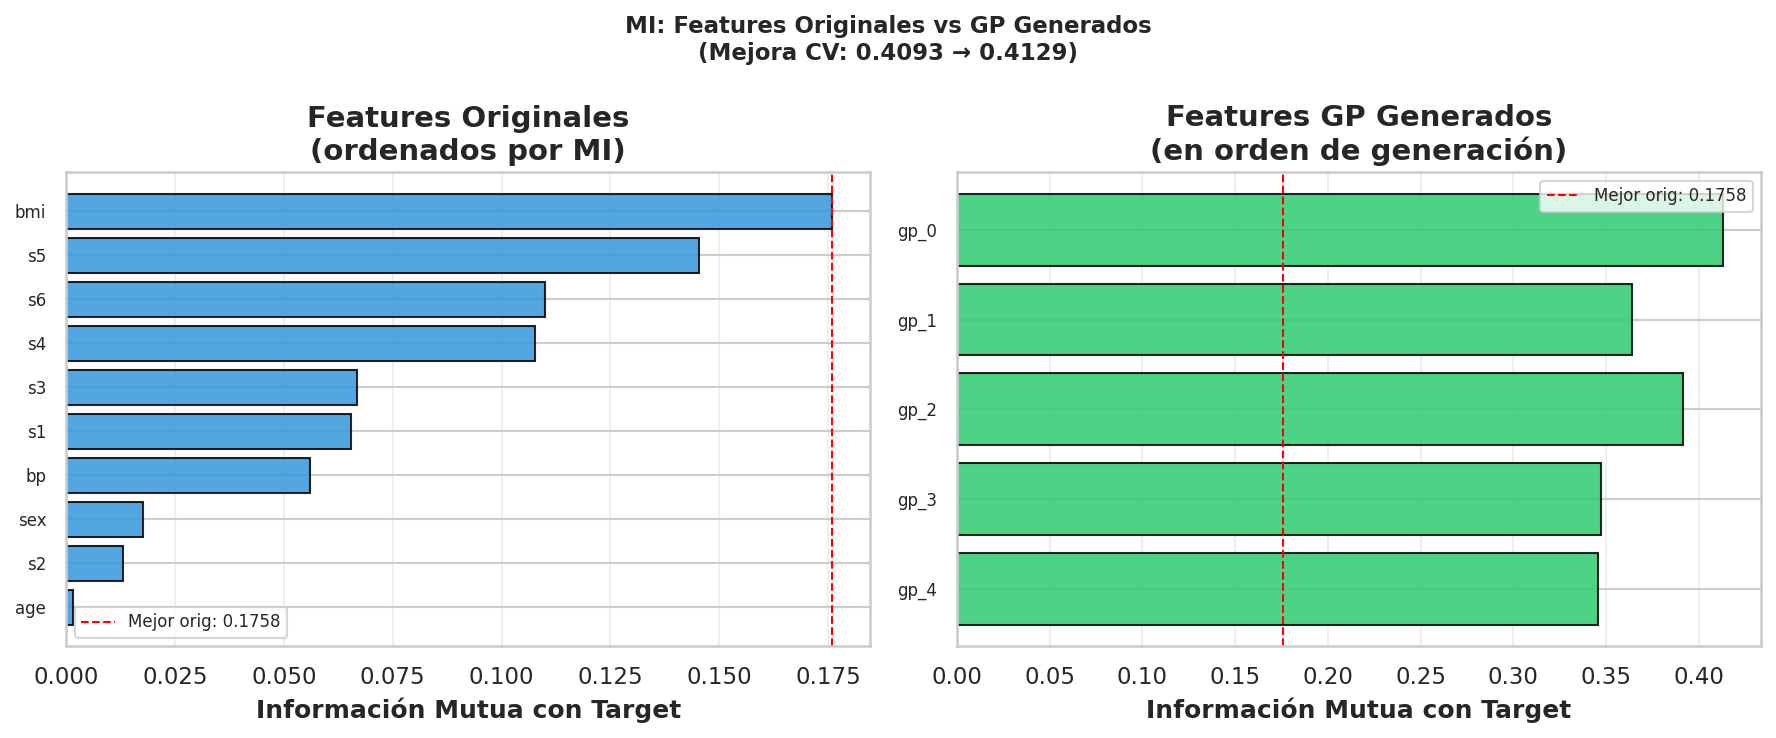

In [8]:
# Usamos el plotter integrado en el framework
GPPlotter.plot_mi_comparison(r_diab, X_diab.values, y_diab.values)

La gráfica demuestra que el GP es capaz de sintetizar variables (ej. `gp_0`) que tienen una correlación no lineal (Información Mutua) con la progresión de la diabetes **muy superior** a cualquier variable original aislada.



### Interpretación Matemática con SymPy


Afirmamos que en el sector médico la interpretabilidad es un requisito legal. Un médico jamás confiará en un modelo de "Caja Negra" que simplemente escupe un diagnóstico. Pero, ¿confiará en un árbol Lisp que dice `mul(x2, add(x8, log(x2)))`? Tampoco.

Un último paso importante es traducir la salida del algoritmo al lenguaje del negocio. Tomamos la mejor característica descubierta por el GP, y usamos la librería de álgebra computacional **SymPy** para simplificar la ecuación y presentarla en un formato matemático tradicional.

In [31]:
import sympy as sp

# 1. Tomamos el mejor feature generado por el GP para Diabetes
mejor_feature_diab = r_diab.generated_features[0]
expr_cruda = mejor_feature_diab.expression

print(f"1. Salida Cruda del GP (Formato Lisp):")
print(f"   {expr_cruda}\n")

# 2. Mapeamos las primitivas de DEAP a funciones matemáticas de SymPy
mapeo_sympy = {
    'add': lambda a, b: a + b,
    'sub': lambda a, b: a - b,
    'mul': lambda a, b: a * b,
    'div': lambda a, b: a / b,  # Asumimos división ideal para la interpretación humana
    'log': lambda a: sp.log(a),
    'sqrt': lambda a: sp.sqrt(a),
    'sq': lambda a: a**2,
    'cube': lambda a: a**3,
    'neg': lambda a: -a,
    'abs': lambda a: sp.Abs(a),
    'sigmoid': lambda a: 1 / (1 + sp.exp(-a)),
    'relu': lambda a: sp.Max(0, a)
}

# 3. Mapeamos los genes (x0, x1...) a los nombres reales del dataset
nombres_clinicos = ds_diabetes.feature_names
# Para cuando se optimiza utilizando una matriz de numpy, los features originales se nombran (x0, x1...)
# Lo dejo a mano por si se experimenta con otros datos
# simbolos_reales = {f'x{i}': sp.Symbol(nombre) for i, nombre in enumerate(nombres_clinicos)}

# En este caso, ingresamos con un dataframe, por lo tanto, se adoptan los nombre reales en los genes
simbolos_reales = {nombre: sp.Symbol(nombre) for nombre in nombres_clinicos}

# Unimos ambos diccionarios para el entorno de evaluación
entorno_evaluacion = {**mapeo_sympy, **simbolos_reales}

try:
    # 4. Evaluamos el string Lisp convirtiéndolo en un objeto SymPy
    expr_sympy = eval(expr_cruda, {"__builtins__": None}, entorno_evaluacion)

    # 5. Simplificamos algebraicamente la ecuación
    expr_limpia = sp.simplify(expr_sympy)

    print(f"2. Ecuación Traducida y Simplificada para el Negocio:")
    print(f"   Nueva_Variable = {expr_limpia}")

except Exception as e:
    print(f"No se pudo simplificar la expresión: {e}")

1. Salida Cruda del GP (Formato Lisp):
   neg(add(div(div(div(add(s5, bmi), -0.7354444220376792), log(1.4774699372826094)), log(add(log(1.4774699372826094), add(1.4774699372826094, s2)))), bmi))

2. Ecuación Traducida y Simplificada para el Negocio:
   Nueva_Variable = (-bmi*log(s2 + 1.86780106035688) + 3.48350918857291*bmi + 3.48350918857291*s5)/log(s2 + 1.86780106035688)


In [32]:
expr_limpia

(-bmi*log(s2 + 1.86780106035688) + 3.48350918857291*bmi + 3.48350918857291*s5)/log(s2 + 1.86780106035688)

Observar la salida simplificada. Aunque la ecuación resultante (ej. `(-bmi*log(s2 + 1.86) + 3.48*bmi + 3.48*s5)/log(s2 + 1.86)`) pueda parecer compleja, **es estrictamente determinista y auditable**.

En lugar de decirle a un auditor médico "el modelo usa una red neuronal de caja negra", podemos presentar la fórmula matemática exacta que relaciona el Índice de Masa Corporal (`bmi`) con los marcadores séricos (`s2`, `s5`).

> El médico puede tomar esta fórmula, graficarla, someterla a pruebas de estrés, contrastarla con la literatura médica existente, validarla clínicamente y aprobar su uso en producción cumpliendo con las normativas legales. **Acabamos de convertir un problema de Machine Learning en un descubrimiento científico auditable.**

### Ablation Study: ¿Cuántos features necesitamos?



Generamos 5 features, pero ¿necesitamos los 5? En ingeniería, menos es más.



In [33]:
print("Ablation study: R² vs número de features GP agregados")
print(f"{'N features GP':>15} | {'R² (5-CV)':>12} | {'Δ vs baseline':>15}")
print("─" * 50)

baseline_r2 = cross_val_score(Ridge(), X_diab, y_diab, scoring='r2', cv=cv5)
print(f"{'0 (baseline)':>15} | {np.mean(baseline_r2):12.4f} | {'—':>15}")

for n_gp in range(1, len(r_diab.generated_features)+1):
    gp_vals = np.column_stack([r_diab.generated_features[i].values for i in range(n_gp)])
    X_aug = np.hstack([X_diab.values, gp_vals])
    scores = cross_val_score(Ridge(), X_aug, y_diab, scoring='r2', cv=cv5)
    delta = np.mean(scores) - np.mean(baseline_r2)
    print(f"{n_gp:>15} | {np.mean(scores):12.4f} | {delta:+15.4f}")


Ablation study: R² vs número de features GP agregados
  N features GP |    R² (5-CV) |   Δ vs baseline
──────────────────────────────────────────────────
   0 (baseline) |       0.4093 |               —
              1 |       0.4625 |         +0.0532
              2 |       0.4180 |         +0.0087
              3 |       0.4174 |         +0.0081
              4 |       0.4161 |         +0.0068
              5 |       0.4129 |         +0.0036


*Conclusión:* Generalmente, el primer y segundo feature aportan el 90% del valor. A partir del tercero, entramos en la ley de rendimientos decrecientes.


**Discusión de Ingeniería: Peligro de la Multicolinealidad**  

Observar detenidamente la tabla de resultados del *Ablation Study*.
*   Con **0 features GP** (Baseline), el $R^2$ es $0,4093$.
*   Al agregar **1 feature GP**, el rendimiento se dispara a $0,4625$ (mejora del +0,05).
*   Pero al agregar el 2do, 3ro, 4to y 5to feature, el rendimiento **cae progresivamente** hasta volver a $0,4129$.

**¿Qué pasó acá?** Acabamos de presenciar el problema clásico de la **Multicolinealidad**. Los modelos lineales (como Ridge simple que estamos usando) son extremadamente sensibles a variables que comparten información. Aunque usamos el parámetro $\beta$ para forzar diversidad, los features generados por el GP inevitablemente tienen cierta correlación entre sí y con las variables originales. Al inyectar 5 variables complejas de golpe, asfixiamos al modelo lineal con información redundante.



> **Criterio Profesional:** Esta es la prueba empírica irrefutable de por qué el GP Feature Engineer **no debe usarse solo**. Necesitamos el paso de **Feature Selection** (como el del notebook [GA como Wrapper para Machine Learning (Feature Selection y HPO)](ga_machine_learning.ipynb)) para que evalúe este dataset aumentado y elimine la basura y la redundancia, quedándose solo con ese "Feature 1" que realmente aportaba valor.

## Análisis de Sensibilidad: El Parámetro $\beta$ (redundancia)



El parámetro $\beta$ es el corazón de nuestra estrategia HFSR. Controla cuánto penalizamos a un árbol si se parece a los que ya descubrimos. Vemos empíricamente cómo afecta la diversidad de las ecuaciones generadas:


In [34]:
betas = [0.0, 0.30, 0.70]
print(f"{'β':>6} | {'Expresiones Únicas':>20} | {'R² Augmented':>15}")
print("─" * 45)

for beta_val in betas:
    cfg_b = GPConfig(population_size=100, n_generations=20, n_features_to_generate=3,
                     redundancy_beta=beta_val, verbose=False)
    eng_b = GPFeatureEngineer(config=cfg_b)
    eng_b.fit(X_diab.values, y_diab.values)

    exprs = [gf.expression for gf in eng_b.result_.generated_features]
    n_unique = len(set(exprs))

    print(f"{beta_val:6.2f} | {n_unique:20d} | {eng_b.result_.augmented_cv_score:15.4f}")


     β |   Expresiones Únicas |    R² Augmented
─────────────────────────────────────────────
  0.00 |                    1 |          0.4693
  0.30 |                    3 |          0.4688
  0.70 |                    3 |          0.4495


**¿Qué dicen estos valores?:**  

*   **$\beta = 0.0$ (R² $\approx 0.469$, Únicas = 1):** Sin penalización, el GP es perezoso. Encontró una buena ecuación y generó 3 copias exactas de la misma. No hay diversidad.
*   **$\beta = 0.3$ (R² $\approx 0.468$, Únicas = 3):** El *Sweet Spot*. El GP se vio forzado a inventar 3 ecuaciones matemáticamente distintas, manteniendo prácticamente el mismo poder predictivo.
*   **$\beta = 0.7$ (R² $\approx 0.449$, Únicas = 3):** Alta penalización. Forzamos tanta diversidad que el GP tuvo que recurrir a ecuaciones subóptimas o ruidosas solo para no parecerse a las anteriores, degradando el rendimiento final del modelo.



> **Conclusión:** Un valor de $\beta \approx 0.3$ garantiza un banco de características diverso y rico en información, ideal para pasarlo a la siguiente etapa de un buen pipeline (Selección de Features).

## El Pipeline Definitivo



Para llevar esto a producción, nuestro `GPFeatureEngineer` fue diseñado heredando de `TransformerMixin` de `scikit-learn`. Esto significa que podemos insertarlo directamente en un `Pipeline` estándar, combinando la creación de features (GP) con la selección de features y el modelo final.



In [13]:
from sklearn.pipeline import Pipeline

# 1. Configuramos el GP (Creador de Features), 1 solamente para velocidad y asentar el ejemplo
config_pipe = GPConfig(n_features_to_generate=1, verbose=False)

# 2. Ensamblamos el Pipeline Híbrido
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gp_engineer', GPFeatureEngineer(config=config_pipe)),
    # Acá podríamos insertar un Selector de Features, debe ser compatible con pipelines...
    # Eliminar colinealidad si queremos usar Rigde, etc etc. según el tipo de modelo
    ('ridge', Ridge(alpha=1.0)),
])

# 3. Entrenamiento y Evaluación End-to-End
print("Entrenando Pipeline completo (Scaler -> GP -> Ridge)...")
cv_pipe = cross_val_score(pipe, X_diab, y_diab, scoring='r2', cv=KFold(3, shuffle=True, random_state=SEED))

print(f"Pipeline CV R²: {np.mean(cv_pipe):.4f} ± {np.std(cv_pipe):.4f}")

Entrenando Pipeline completo (Scaler -> GP -> Ridge)...
Pipeline CV R²: 0.4784 ± 0.0388


Conseguimos un pequeño plus, el $R^2$ ahora es **0,478**. Al integrar el GP dentro de un pipeline formal con `StandardScaler`, estabilizamos numéricamente las entradas, permitiendo que el modelo Ridge aproveche al máximo las nuevas características. Resta mucho por hacer, pero de los capítulos anteriores deberían de tener las bases para un pipeline robusto y efectivo, incorporando "lo nuevo" que es delegar la parte dura del FE a un algoritmo genético.

**NOTA**: una implementación avanzada (y compatible con Pipeline) del Selector de Features con AG implementado de manera minimalista en el notebook [GA como Wrapper para Machine Learning (Feature Selection y HPO)](ga_machine_learning.ipynb), se encuentra en: [evo-suite](https://evo-suite.readthedocs.io/en/latest/)

## Lecciones de Ingeniería y Limitaciones



1. **Costo Computacional:** La Programación Genética es costosa. Su complejidad es $O(\text{features} \times \text{generaciones} \times \text{población} \times \text{muestras})$. No se ejecuta en cada iteración de entrenamiento, sino **una sola vez** durante la fase de descubrimiento de datos (EDA avanzado).
2. **Overfitting de Features:** Al generar miles de árboles, es posible que el GP encuentre una fórmula que se ajuste perfectamente al ruido del set de entrenamiento. Es importante seleccionar los features útiles, o incorporar un modelo que lo haga de manera nativa. Incluso con todo esto, es **vital** evaluar el pipeline final en un conjunto de Test estrictamente separado (lo que venimos mencionando desde siempre).
3. **El Poder de la Caja Blanca:** Demostramos que no siempre necesitamos sacrificar la interpretabilidad usando Redes Neuronales o XGBoost. Con GP, podemos dotar a modelos lineales simples de la capacidad de entender el mundo no lineal, manteniendo las ecuaciones a la vista de todos.

## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
IPython,7.34.0
deap,1.4
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
